For the entire assignment:

✅ Allowed:
- torch.Tensor operations
- loss.backward()

❌ Not allowed:
- torch.optim.*
- torch.nn.Linear (and generally torch.nn layers)
- high-level loss modules (nn.MSELoss, etc.) — compute MSE manually
- high-level training wrappers (Lightning, fastai, Trainer APIs)

In [ ]:
import torch
import numpy as np

np.random.seed(42)

# Task 1 — Multivariate Linear Regression + Manual Training Loop (3 pts)

We consider the model:

$$
\hat y = XW+b
$$


Where:

* $ X \in \mathbb R^{N×d} $ 


* $W \in \mathbb R^{d×1}$
* $b \in \mathbb R$

Prepare a dataset with at least 300 samples and at least 3 features:

Option A: use a real dataset (recommended), e.g. California Housing (you may use sklearn.datasets.fetch_california_housing() only for loading data, not modeling),

Option B: generate synthetic data with d ≥ 3.

In [68]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

data = fetch_california_housing(as_frame=True)

print(f"Features: {data.feature_names}")
print(f"Target: {data.target_names}")

X = data.data
y = data.target

Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target: ['MedHouseVal']


Split data into train / validation (e.g., 80% / 20%).

In [69]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X,y, test_size=0.2, random_state=42)

Normalize features using statistics from the training set:
$$
X' = \frac{X-\mu}{\sigma}
$$

In [70]:
X_train_mean = X_train.mean()
X_train_var = X_train.var()

Xn_train = (X_train - X_train_mean) / X_train_var
Xn_val = (X_val - X_train_mean) / X_train_var
Xn_train

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
14196,-0.171290,0.027652,-0.073265,-0.480961,0.000676,0.004437,-0.642482,0.634480
8267,-0.018822,0.128393,-0.168731,-0.296680,-0.000087,-0.010136,-0.410298,0.353571
17445,0.075985,-0.154942,0.036950,-0.594463,-0.000396,-0.002788,-0.215351,-0.223164
14265,-0.534494,0.046541,-0.251321,-0.335058,-0.000007,0.006694,-0.646863,0.614593
2271,-0.090051,0.090615,0.146184,0.199951,-0.000427,-0.005944,0.249018,-0.054121
...,...,...,...,...,...,...,...,...
11284,0.686436,0.040244,0.121728,-0.908046,-0.000594,-0.000483,-0.408108,0.403289
11964,-0.229089,0.027652,0.251486,0.920757,0.000253,0.006021,-0.355538,0.535043
5390,-0.260967,0.046541,-0.254146,-0.090520,0.000255,0.001754,-0.353347,0.298880
860,0.506971,-0.085682,0.168454,-0.152957,0.000271,0.000611,0.424251,-0.591081


Initialize parameters:

`W ~ N(0,1)` (shape `d x 1`)

`b ~ N(0,1)` (scalar)

with `requires_grad=True`.

In [ ]:
N,d = Xn_train.shape

torch.manual_seed(42)

W = torch.randn(d, 1, requires_grad=True)
b = torch.randn(1, requires_grad=True)



5. Implement:

* forward pass,
* **MSE loss manually**:

$$
MSE = \frac{1}{N} \sum_{i=1}^{N} \left(\hat y_i-y_i\right)^2
$$

* training loop for 200–1000 epochs,
* manual gradient descent update using `torch.no_grad()`:
  * update `W`, `b`,
  * then reset gradients correctly.

In [72]:
Xn_train = torch.tensor(Xn_train.values, dtype = torch.float32)
Xn_val = torch.tensor(Xn_val.values, dtype = torch.float32)
y_train = torch.tensor(y_train.values, dtype=torch.float32).reshape(-1,1)# without this y_train has shape (N,1) which causes massive broadcasting later during every subtraction to calculate mse loss, which makes the loop of epochs compuet in 5 minutes insetad of 1 second
y_val = torch.tensor(y_val.values, dtype=torch.float32).reshape(-1,1)

In [73]:
y_train.shape

torch.Size([16512, 1])

In [74]:
lr = 0.01
epochs = range(300)

Train_loss = []
Validation_loss = []

for epoch in epochs:
    y_pred = Xn_train @ W + b
    y_val_pred = Xn_val @ W + b

    mse_loss = torch.mean((y_train - y_pred) ** 2)
    mse_val_loss = torch.mean((y_val - y_val_pred) ** 2)

    Train_loss.append(mse_loss.item())
    Validation_loss.append(mse_val_loss.item())
    
    mse_loss.backward()

    with torch.no_grad():
        W -= lr * W.grad
        b -= lr * b.grad

    W.grad = None
    b.grad = None

**Why `torch.no_grad()`?**

Parameter updates should not be part of the computational graph.

**Why must we reset gradients each iteration?**

Because the in torch, the gradients stored in our tensors accumulate instead of overwriting the previous value.
So every call of `.backwards` adds to the `.grad` value, which we dont't want for this task.

**Why does feature normalization typically help optimization?**

Normalization techniques are often theoretically justified as reducing covariance shift, smoothing optimization landscapes, and increasing regularization, though they are mainly justified by empirical success. <<<< Wikipedia

Some sites cite feature dominance as a potential problem during gradient calculations.

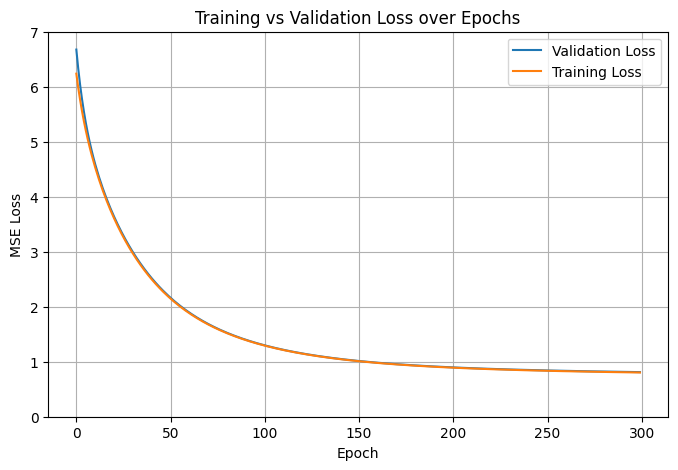

In [75]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(epochs, Validation_loss, label="Validation Loss")
plt.plot(epochs, Train_loss, label="Training Loss")


plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss over Epochs")
plt.legend()
plt.yticks(range(0,8))
plt.grid(True)

plt.show()

# Task 2 — Closed-Form Solution (Normal Equation) (2 pts)

⚠ **This task is a direct continuation of Task 1.**

You must use:

* The **same dataset**
* The **same train/validation split**
* The **same feature normalization**
* The **same training set** for computing parameters

In Task 1, you trained the model using **gradient descent**.

In this task, you will compute the **analytical solution** for linear regression and compare it to the gradient descent solution.


Recall that for linear regression with MSE loss, the optimal parameters can be obtained by solving:

$$
W^* = (X^TX)^{-1} X^T y
$$

You may use:

* `torch.linalg.solve` or `torch.linalg.pinv`

It is recommended to include the bias term by augmenting the input matrix with a column of ones.

### Requirements


1. Compute *W\** (and *b* if you separate it).
2. Compute training and validation MSE for:
   * Gradient Descent solution
   * Closed-form solution
3. Compare the results.

In [76]:
Xn_train_aug = torch.cat([Xn_train, torch.ones(Xn_train.shape[0], 1)], dim=1)
Xn_val_aug = torch.cat([Xn_val, torch.ones(Xn_val.shape[0], 1)], dim=1)

In [77]:
W_and_b = torch.linalg.pinv(Xn_train_aug) @ y_train

Moore Penrose pseudoinverse

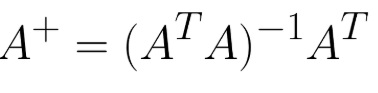

In [78]:
y_pred_cl = Xn_train_aug @ W_and_b
y_val_pred_cl = Xn_val_aug @ W_and_b

In [79]:
mse_loss = torch.mean((y_pred_cl - y_train) ** 2)
mse_val_loss = torch.mean((y_val_pred_cl - y_val) ** 2)

In [80]:
print(f"Gradient Descent {epochs.stop} epochs:")
print("Train MSE:", Train_loss[-1])
print("Val MSE:", Validation_loss[-1])

print("\nClosed Form Solution:")
print("Train MSE:", mse_loss.item())
print("Val MSE:", mse_val_loss.item())

Gradient Descent 300 epochs:
Train MSE: 0.8041165471076965
Val MSE: 0.8109931349754333

Closed Form Solution:
Train MSE: 0.5179378390312195
Val MSE: 0.5559532642364502


**When is the closed-form solution feasible, and when is it not?**

We should avoid the closed-form solution when dealing with lots of features, which are dense(non-zero). As this solution gets progressively slower and more memory expensive than the GD solution with higher number of features, we might be concerned about numerical correctness as well in case of the closed form solution. >>>
https://stats.stackexchange.com/questions/23128/solving-for-regression-parameters-in-closed-form-vs-gradient-descent

**Why might gradient descent not match the closed-form result exactly (even on convex problems)?**

This is due to the limited number of epochs, the learning rate which may prevent us from reaching the exact optimum, as well as numericall precision and floatin-point erros, which may cause small differences.

# Bonus Task — Conditioning & Geometry (+2 pts)

## Part A — Condition Number Analysis

For linear regression with MSE loss, the curvature of the loss surface is determined by $X^TX$.

Compute the **condition number**:

$$
\kappa(X^T X) = \frac{\lambda_{\max}}{\lambda_{\min}},
$$

where

* $⁡\lambda_{\max}$​ is the largest eigenvalue,
* $\lambda_{\min}$​ is the smallest eigenvalue.

### Requirements


1. Compute $\kappa(X^T X)$ using:
   * Raw (non-normalized) features
   * Normalized features (as in Task 1)

In [81]:
X_train = torch.tensor(X_train.values, dtype = torch.float32)


XtX_raw = X_train.T @ X_train
XtX_norm = Xn_train.T @ Xn_train

In [82]:
eigvals_raw = torch.linalg.eigvalsh(XtX_raw)
eigvals_norm = torch.linalg.eigvalsh(XtX_norm)

eigvals_norm_min = min(eigvals_norm)
eigvals_norm_max = max(eigvals_norm)
eigvals_raw_min = min(eigvals_raw)
eigvals_raw_max = max(eigvals_raw)

In [83]:
condition_number_norm = eigvals_norm_max/eigvals_norm_min
condition_number_raw = eigvals_raw_max/eigvals_raw_min

print(f"Condition number for normalized data: {condition_number_norm}")
print(f"Condition number for raw data: {condition_number_raw}")
print(f"Scale ratio: {condition_number_raw/condition_number_norm}")

Condition number for normalized data: 7975526.5
Condition number for raw data: 120720128.0
Scale ratio: 15.136321067810059


**Is the condition number larger without normalization?**

Yes. Mostly due to the different scales of every feature in the raw data.

**What does a large condition number indicate?**

In numerical analysis, the condition number of a function measures how much the output value of the function can change for a small change in the input argument. This is used to measure how sensitive a function is to changes or errors in the input, and how much error in the output results from an error in the input.

So a large condition number indicates that a small difference in our input may create wildly different outputs.

**What happens if $ \lambda_{\min} \approx 0 $?**

It means that the matrix is nearly singular, which makes the inverse operation $ (X^TX)^{-1} $ highly unstable.

## Part B — Loss Surface Geometry

To understand the shape of the loss function:


1. Select **two parameters** $w_i, w_j$​.
2. Fix all other parameters.
3. Evaluate the loss on a grid of values for $w_i, w_j$​.
4. Plot contour lines of the loss surface.

Repeat for:

* raw features
* normalized features

In [84]:
w1_range = torch.linspace(-10, 10, 250)
w2_range = torch.linspace(-10, 10, 250)

W_constant = W.clone().detach()
loss_norm_grid = torch.zeros(len(w1_range), len(w2_range))
loss_raw_grid = torch.zeros(len(w1_range), len(w2_range))

In [85]:
with torch.no_grad():
    for x, w1 in enumerate(w1_range):
        for z, w2 in enumerate(w2_range):    
                
                W_temp = W_constant.clone()

                W_temp[0] = w1 #med income
                W_temp[4] = w2 #x

                yn_temp_pred = Xn_train @ W_temp
                y_temp_pred = X_train @ W_temp
                loss_norm = torch.mean((yn_temp_pred - y_train)**2)
                loss_raw = torch.mean((y_temp_pred - y_train)**2)

                loss_norm_grid[x, z] = loss_norm.item()
                loss_raw_grid[x, z] = loss_raw.item()

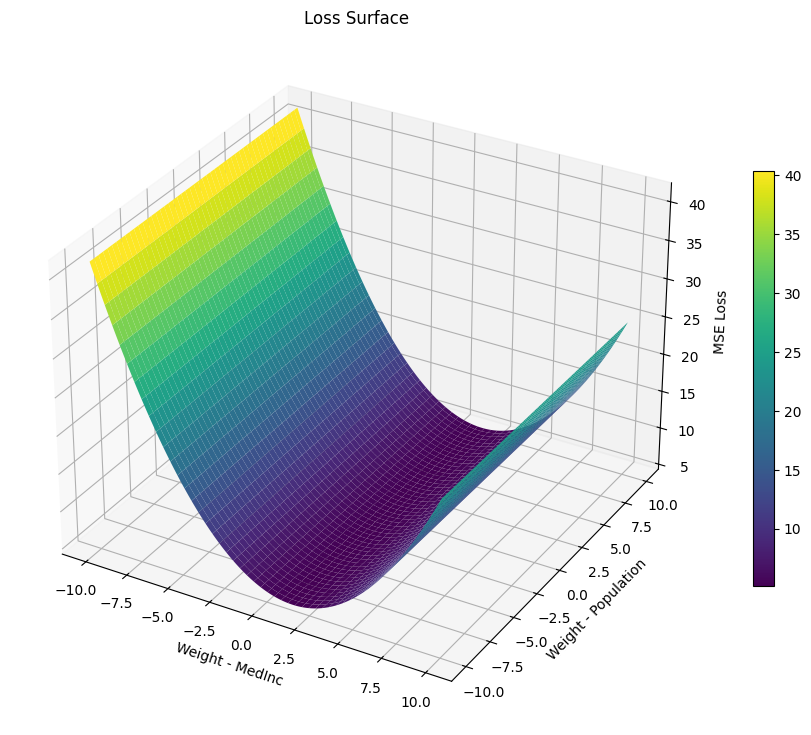

In [128]:
W1, W2 = np.meshgrid(w1_range.numpy(), w2_range.numpy())

fig = plt.figure(figsize=(13,9))
ax = fig.add_subplot(111, projection='3d')

surface = ax.plot_surface(
    W1,
    W2,
    loss_norm_grid.numpy().T,
    cmap="viridis"
)

ax.set_xlabel("Weight - MedInc")
ax.set_ylabel("Weight - Population")
ax.set_zlabel("MSE Loss")

ax.set_title("Loss Surface")

fig.colorbar(surface, ax=ax, shrink=0.6)

plt.show()

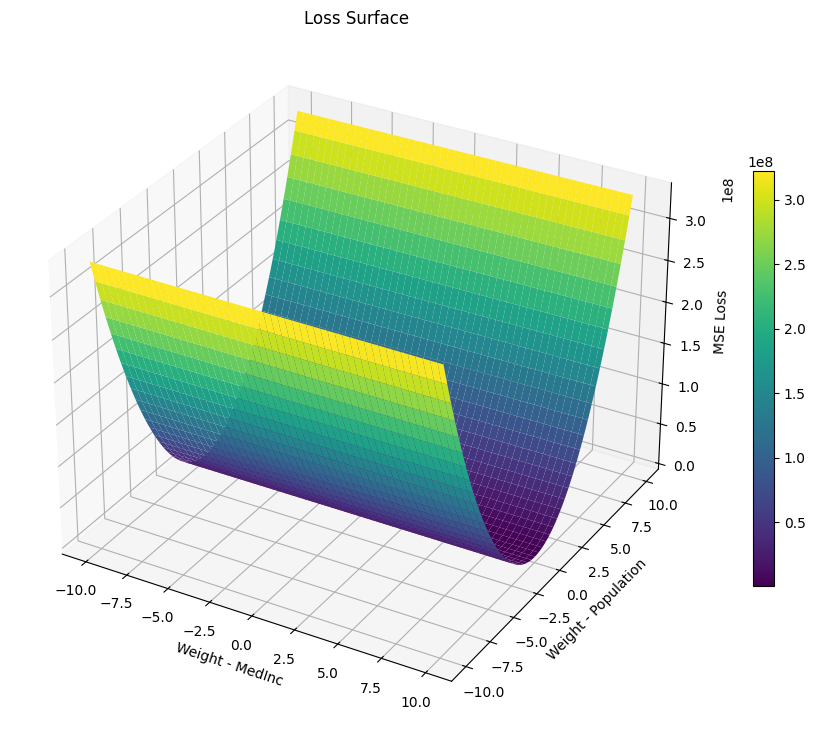

In [129]:
fig = plt.figure(figsize=(13,9))
ax = fig.add_subplot(111, projection='3d')

surface = ax.plot_surface(
    W1,
    W2,
    loss_raw_grid.numpy().T,
    cmap="viridis"
)

ax.set_xlabel("Weight - MedInc")
ax.set_ylabel("Weight - Population")
ax.set_zlabel("MSE Loss")

ax.set_title("Loss Surface")

fig.colorbar(surface, ax=ax, shrink=0.6)

plt.show()

In [88]:
X_train_mean

MedInc           3.880754
HouseAge        28.608285
AveRooms         5.435235
AveBedrms        1.096685
Population    1426.453004
AveOccup         3.096961
Latitude        35.643149
Longitude     -119.582290
dtype: float64


**What is the shape of the contours without normalization?**
**What is the shape after normalization?**
**Are they circular or elongated?**

In the case of Income and Population they both look like a wave, altough features like latitude and longitude give us a more standard valley-like shape. What changed is that in the normalized loss surface the MedInc's Weight matters more thus the waves orientation along its axis. But on the raw non normalized data the wave 'turned' and is now sensitive to the change in Population, because the mean of Population is 1426.4 in comparison to MedInc's 3.8.


**How does this relate to the condition number?**

The condition number shows us how much a small change in input can affect the output. As we can see on the plots above the normalized loss function ranges from ~0 to 40, with weight between -10 and 10, while on the second plot the curvature of the surface is much steeper, ranging from ~0 to 3 * 1e8 so about 300.000.000 while using the same weight range.

# Task 3 — Optimization Study (2 pts)

Run controlled experiments to study optimization behavior.

### Requirements

Train the same model while changing only the **learning rate**.

Test at least 3 learning rates:

* **too small** (slow learning)
* **reasonable**
* **too large** (divergence or oscillations)

For each learning rate:

* plot training loss curve,
* report final train/val MSE.

Additionally, track and plot the gradient norm per epoch:

$$
\left \| \nabla_W L \right\|_2
$$

### Required Explanation (Markdown)

* What does divergence look like in the loss curve?
* Explain why too-large learning rate causes instability.
* How does **normalization** affect the range of “reasonable” learning rates?

In [123]:
def train_model(lr, epochs=300):

    torch.manual_seed(42)
    W = torch.randn(d, 1, requires_grad=True)
    b = torch.randn(1, requires_grad=True)

    train_losses = []
    val_losses = []
    grad_norms = []

    for epoch in range(epochs):

        y_pred = Xn_train @ W + b
        y_val_pred = Xn_val @ W + b

        mse_loss = torch.mean((y_train - y_pred) ** 2)
        mse_val_loss = torch.mean((y_val - y_val_pred) ** 2)

        train_losses.append(mse_loss.item())
        val_losses.append(mse_val_loss.item())

        mse_loss.backward()

        grad_norm = torch.norm(W.grad).item()
        grad_norms.append(grad_norm)

        with torch.no_grad():
            W -= lr * W.grad
            b -= lr * b.grad

        W.grad = None
        b.grad = None

    return train_losses, val_losses, grad_norms

In [124]:
lrs = [0.0000001, 0.01, 0.2]

results = {}

for lr in lrs:
    results[lr] = train_model(lr)

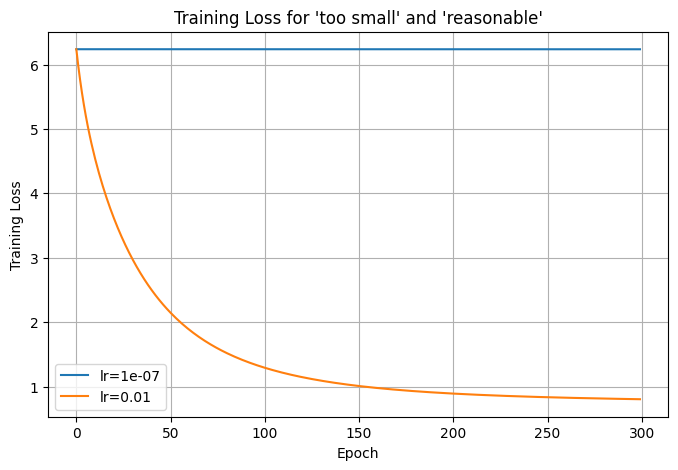

In [125]:
plt.figure(figsize=(8,5))

for lr in lrs[:-1]:
    train_losses, _, _ = results[lr]
    plt.plot(train_losses, label=f"lr={lr}")

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss for 'too small' and 'reasonable'")
plt.legend()
plt.grid()

plt.show()

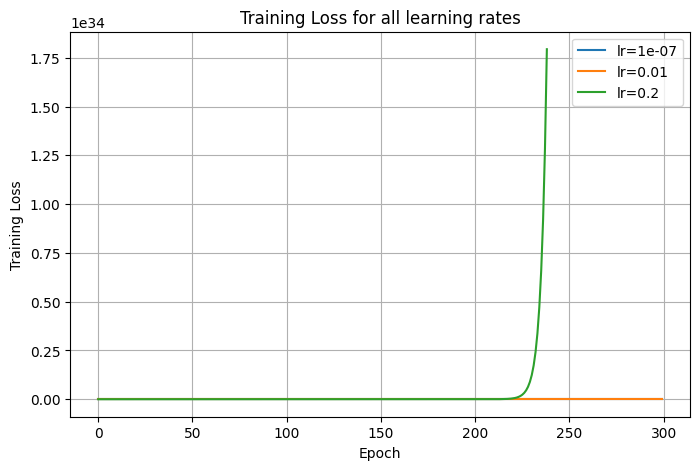

In [126]:
plt.figure(figsize=(8,5))

for lr in lrs:
    train_losses, _, _ = results[lr]
    plt.plot(train_losses, label=f"lr={lr}")

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss for all learning rates")
plt.legend()
plt.grid()

plt.show()

**What does divergence look like in the loss curve?**
↑↑↑↑Like this?↑↑↑↑

 From what i read it can either grow exponentially or oscillate wildly between large values.

In [127]:
for lr in results:
    train_losses, val_losses, _ = results[lr]

    print(f"Learning rate {lr}")
    print("Final Train MSE:", train_losses[-1])
    print("Final Val MSE:", val_losses[-1])
    print()

Learning rate 1e-07
Final Train MSE: 6.236541748046875
Final Val MSE: 6.6743693351745605

Learning rate 0.01
Final Train MSE: 0.8041165471076965
Final Val MSE: 0.8109931349754333

Learning rate 0.2
Final Train MSE: inf
Final Val MSE: inf



**Why does a too-large learning rate cause instability?**

If the learning rate is too large, the update step becomes too big and the algorithm overshoots the minimum of the loss function. Instead of moving toward the minimum, the parameters jump across it repeatedly, causing oscillations or divergence.

**How does normalization affect the range of reasonable learning rates?**

It transforms the means and variations of every feature to similar values, which makes the loss surface more symetric. Without normalization, the loss surface can be highly stretched.